In [1]:
import matplotlib.pyplot as plt
from kneed import KneeLocator
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs
from sklearn.metrics import silhouette_score

In [2]:
features, true_lables = make_blobs(n_samples=200, centers=3, cluster_std=2.75, random_state=42)

In [5]:
features[:5]

array([[  9.77075874,   3.27621022],
       [ -9.71349666,  11.27451802],
       [ -6.91330582,  -9.34755911],
       [-10.86185913, -10.75063497],
       [ -8.50038027,  -4.54370383]])

In [6]:
true_lables[:5]

array([1, 0, 2, 2, 2])

In [7]:
scaler = StandardScaler()

In [8]:
scaled_features = scaler.fit_transform(features)
scaled_features[:5]

array([[ 2.13082109,  0.25604351],
       [-1.52698523,  1.41036744],
       [-1.00130152, -1.56583175],
       [-1.74256891, -1.76832509],
       [-1.29924521, -0.87253446]])

In [9]:
k_means = KMeans(init="random", n_clusters=3, n_init=10, max_iter=300, random_state=42)

In [10]:
k_means.fit(scaled_features)

KMeans(init='random', n_clusters=3, n_init=10, random_state=42)

In [11]:
k_means.inertia_

74.57960106819854

In [13]:
k_means.cluster_centers_

array([[ 1.19539276,  0.13158148],
       [-0.25813925,  1.05589975],
       [-0.91941183, -1.18551732]])

In [14]:
k_means.n_iter_

10

In [15]:
k_means.labels_[:5]

array([0, 1, 2, 2, 2], dtype=int32)

In [16]:
kmeans_kwargs = {
   "init": "random",
   "n_init": 10,
   "max_iter": 300,
   "random_state": 42,
   }
   
# A list holds the SSE values for each k
sse = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, **kmeans_kwargs)
    kmeans.fit(scaled_features)
    sse.append(kmeans.inertia_)

Text(0, 0.5, 'SSE')

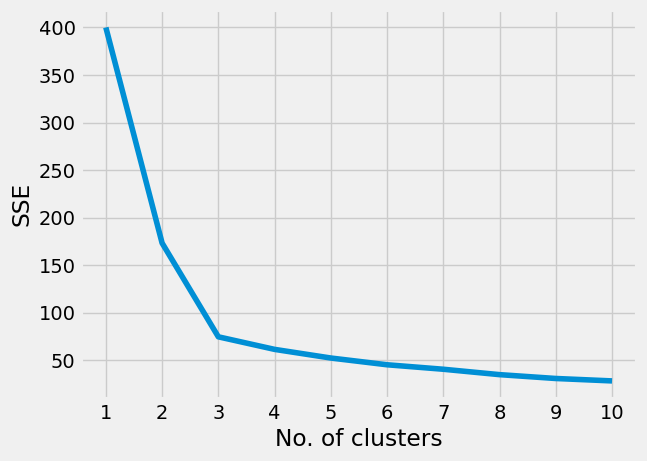

In [18]:
plt.style.use("fivethirtyeight");
plt.plot(range(1,11), sse);
plt.xticks(range(1, 11))
plt.xlabel("No. of clusters");
plt.ylabel("SSE")

In [19]:
kl = KneeLocator(range(1, 11), sse, curve="convex", direction="decreasing")
kl.elbow

np.int64(3)